In [45]:
import pandas as pd

In [46]:
df = pd.read_csv('train.csv')

In [47]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [49]:
y = df['Survived']

In [50]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [51]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [52]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df = pd.get_dummies(df,
                   columns = ['Embarked'],
                   drop_first = True)

In [53]:
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [54]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,False,True


In [55]:
X = df[['Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'Embarked_Q',
        'Embarked_S']]

y = df['Survived']

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
import numpy as np

In [59]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [60]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
    def fit(self, X, y):
        m,n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0

        for _ in range(self.epochs):
            linear = np.dot(X, self.weights) + self.bias
            predictions = sigmoid(linear)
            dw = (1/m) * np.dot(X.T, (predictions - y))
            db = (1/m) * np.sum(predictions - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        probs = sigmoid(linear)
        return (probs >= 0.5).astype(int)

In [61]:
model = LogisticRegressionScratch(
            lr=0.01,
            epochs=5000)

model.fit(X_train, y_train)

In [62]:
predictions = model.predict(X_test)

accuracy = np.mean(predictions == y_test)

print("Scratch Accuracy:", accuracy)

Scratch Accuracy: 0.8044692737430168


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

sk_model = LogisticRegression()

sk_model.fit(X_train, y_train)

sk_preds = sk_model.predict(X_test)

print(
    "Scikit Accuracy:",
    accuracy_score(y_test, sk_preds)
)

Scikit Accuracy: 0.8100558659217877


In [65]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [66]:
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[90 15]
 [20 54]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



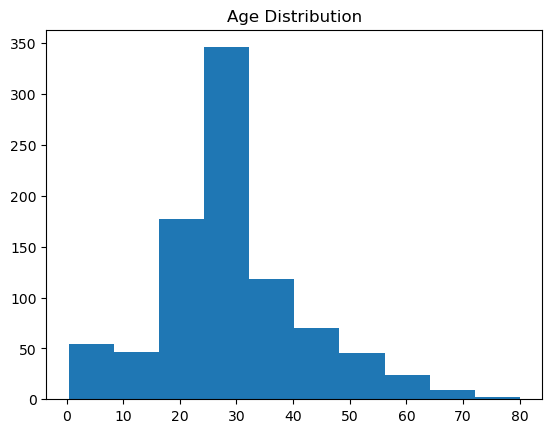

In [67]:
import matplotlib.pyplot as plt

plt.hist(df['Age'])
plt.title("Age Distribution")
plt.show()

In [68]:
pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
0,468,109
1,81,233
